In [1]:
# Chạy ô này trước và chọn đúng một file predictive_maintenance.csv từ máy bạn.
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Đã đọc {filename}: {df.shape[0]:,} dòng, {df.shape[1]} cột")
display(df.head())

Đã đọc predictive_maintenance.csv: 10,000 dòng, 10 cột


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# Predictive Maintenance — Baseline, Data Mismatch & Multi-task Learning

Notebook giải ba phần của bài tuần 7 bằng **PyTorch trên CPU**. Trên Google Colab,
chạy các ô từ trên xuống; dùng file CSV đi kèm đề, không cần cài thêm thư viện.
Các biểu đồ sẽ xuất hiện ngay dưới ô code tạo ra chúng.
Notebook đã lưu sẵn kết quả chạy bằng CSV đi kèm trên Python 3.14/PyTorch CPU ở máy cục bộ;
chỉ thao tác upload được mô phỏng khi kiểm tra. Khi chạy trên Colab, ô đầu sẽ mở hộp chọn file thật.
Phiên bản thư viện khác nhau có thể làm số liệu thay đổi nhẹ dù cùng seed.

- **A:** Dự đoán máy hỏng bằng Dense Neural Network, tránh leakage và đánh giá lớp hiếm.
- **B:** So sánh train, dev gần phân phối train và dev lệch phân phối.
- **C:** Thêm nhiệm vụ dự đoán loại lỗi, kiểm tra tác động lên nhiệm vụ chính.

Trong CSV, `Target` chính là **Machine failure**: 0 = không hỏng, 1 = hỏng.
Mỗi dòng được xem là một mẫu điều kiện vận hành. Ta giả định cảm biến và độ mòn
đã có sẵn khi dự đoán. Dữ liệu không cung cấp mốc thời gian/lịch sử đủ để khẳng định
đây là dự báo *hỏng trong 24 giờ tới*; notebook giải bài phân loại theo nhãn có sẵn.

Các lựa chọn được cố định trước khi xem kết quả. Đây là thí nghiệm học tập trên dev,
chưa phải đánh giá cuối cùng trên một test set độc lập.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, average_precision_score, ConfusionMatrixDisplay,
    PrecisionRecallDisplay, classification_report,
)
from IPython.display import display, Markdown

SEED = 42  # Cố định phép chia dữ liệu và khởi tạo mạng để dễ chạy lại.
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": False})
print("PyTorch:", torch.__version__, "| Thiết bị: CPU")

PyTorch: 2.13.0+cpu | Thiết bị: CPU


## A. Hiểu dữ liệu và loại bỏ leakage

Trước khi học, xem kiểu dữ liệu, giá trị thiếu và tỷ lệ máy hỏng. Nếu phần lớn máy
không hỏng, mô hình luôn trả lời “không hỏng” vẫn có accuracy cao nhưng không phát
hiện được sự cố nào. Ta dùng mô hình ngây thơ này làm mốc để hiểu metric.

,dtype,missing
UDI,int64,0
Product ID,str,0
Type,str,0
Air temperature [K],float64,0
Process temperature [K],float64,0
Rotational speed [rpm],int64,0
Torque [Nm],float64,0
Tool wear [min],int64,0
Target,int64,0
Failure Type,str,0


Tỷ lệ máy hỏng: 3.39%
Luôn đoán không hỏng: accuracy = 96.61%, recall = 0%


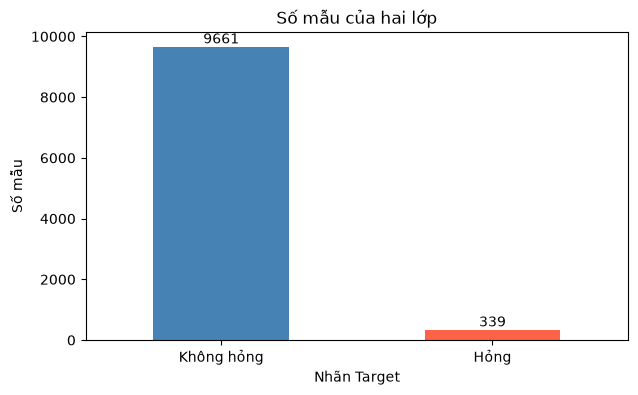

In [3]:
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum()}))
assert df.isna().sum().sum() == 0, "CSV bài tập cần không có giá trị thiếu."
failure_rate = df["Target"].mean()
print(f"Tỷ lệ máy hỏng: {failure_rate:.2%}")
print(f"Luôn đoán không hỏng: accuracy = {1 - failure_rate:.2%}, recall = 0%")

counts = df["Target"].value_counts().reindex([0, 1])
ax = counts.plot.bar(color=["steelblue", "tomato"], rot=0)
ax.set_xticklabels(["Không hỏng", "Hỏng"])
ax.set(title="Số mẫu của hai lớp", ylabel="Số mẫu", xlabel="Nhãn Target")
ax.bar_label(ax.containers[0])
plt.show()

### Đầu vào nào có thể biết tại thời điểm dự đoán?

| Cột | Cách dùng và lý do |
|---|---|
| `Type` | Đầu vào: loại sản phẩm L/M/H đã biết trước sự cố. |
| Nhiệt độ, tốc độ quay, torque, tool wear | Đầu vào: các phép đo vận hành, với giả định có sẵn khi dự đoán. |
| `UDI`, `Product ID` | Bỏ: mã định danh có thể tạo liên hệ giả theo mã/thứ tự, không phải đại lượng vận hành. |
| `Target` | Nhãn chính, tuyệt đối không cho vào X. |
| `Failure Type` | Nhãn về kết quả sự cố; bỏ khỏi X, chỉ làm nhãn phụ ở phần C. |

**Target-derived feature** là feature được tạo từ nhãn hoặc thông tin tiết lộ kết quả.
Không cần chứng minh `Failure Type` được tính trực tiếp từ `Target`: biết loại lỗi thật
đã là biết thông tin về kết quả mà lúc cần dự đoán thường chưa có.
Chia train/dev không chữa được leakage nếu cột này vẫn nằm trong đầu vào của cả hai.

Bảng dưới kiểm tra quan hệ giữa hai nhãn. Ta giữ nguyên các dòng nhãn không khớp,
vì chưa có căn cứ để tự sửa đáp án của bộ dữ liệu.

In [4]:
display(pd.crosstab(df["Failure Type"], df["Target"]))
revealed_answer = (df["Failure Type"] != "No Failure").astype(int)
print(f"Đoán bằng loại lỗi thật khớp {accuracy_score(df['Target'], revealed_answer):.2%} số dòng.")
print("Số dòng không khớp quy tắc này:", (revealed_answer != df["Target"]).sum())
print("Đây là minh họa leakage trên dữ liệu, không phải kết quả mô hình hợp lệ.")

numeric_columns = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
]
feature_columns = ["Type"] + numeric_columns
assert np.isfinite(df[numeric_columns].to_numpy()).all()

Target,0,1
Failure Type,,
Heat Dissipation Failure,0,112
No Failure,9643,9
Overstrain Failure,0,78
Power Failure,0,95
Random Failures,18,0
Tool Wear Failure,0,45


Đoán bằng loại lỗi thật khớp 99.73% số dòng.
Số dòng không khớp quy tắc này: 27
Đây là minh họa leakage trên dữ liệu, không phải kết quả mô hình hợp lệ.


### Chia dữ liệu một lần để dùng chung cho A, B và C

Để phần B có một tình huống mismatch rõ ràng, ta giả lập môi trường triển khai
có nhiều dụng cụ đã mòn hơn dữ liệu huấn luyện:

1. Gọi `Tool wear >= 200 phút` là nhóm độ mòn cao. **200 là mốc tròn do ta chọn
   để thiết kế thí nghiệm**, không phải ngưỡng hỏng đã được xác nhận.
2. Giữ lại **70% nhóm độ mòn cao** và **10% nhóm còn lại** làm mismatched-dev.
   Hai tỷ lệ này có mục đích làm nhóm độ mòn cao xuất hiện nhiều hơn trong dev.
3. Phần còn lại chia **80% train / 20% matched-dev**, lấy ngẫu nhiên và stratify
   theo `Target` để giữ tỷ lệ hai lớp gần nhau. Stratify cũng được dùng trong bước 2.

Các tập không chồng lấn. Matched-dev gần phân phối **train sau khi đã giữ lại mismatch**,
không nhất thiết giống phân phối của toàn bộ CSV. Phần A chỉ dùng train và matched-dev;
phần B mới đánh giá trên mismatched-dev. Không fit preprocessing trên dev.

In [5]:
high_wear = df["Tool wear [min]"] >= 200
remaining_parts, mismatch_parts = [], []

for group, held_out_fraction in [(df[high_wear], 0.70), (df[~high_wear], 0.10)]:
    remaining, held_out = train_test_split(
        group, test_size=held_out_fraction,
        stratify=group["Target"], random_state=SEED,
    )
    remaining_parts.append(remaining)
    mismatch_parts.append(held_out)

remaining = pd.concat(remaining_parts)
mismatch_df = pd.concat(mismatch_parts)
train_df, matched_df = train_test_split(
    remaining, test_size=0.20, stratify=remaining["Target"], random_state=SEED,
)
splits = {"Train": train_df, "Matched-dev": matched_df, "Mismatched-dev": mismatch_df}

assert set(train_df.index).isdisjoint(matched_df.index)
assert set(train_df.index).isdisjoint(mismatch_df.index)
assert set(matched_df.index).isdisjoint(mismatch_df.index)
assert sum(len(frame) for frame in splits.values()) == len(df)

split_summary = pd.DataFrame({
    name: {"Số mẫu": len(frame), "Số máy hỏng": int(frame["Target"].sum()),
           "Tỷ lệ hỏng": frame["Target"].mean(),
           "Tỷ lệ độ mòn >= 200": (frame["Tool wear [min]"] >= 200).mean()}
    for name, frame in splits.items()
}).T
display(split_summary.round(3))

,Số mẫu,Số máy hỏng,Tỷ lệ hỏng,Tỷ lệ độ mòn >= 200
Train,6815.0,185.0,0.027,0.029
Matched-dev,1704.0,46.0,0.027,0.024
Mismatched-dev,1481.0,108.0,0.073,0.379


### Chuẩn hóa và mã hóa

Mạng Dense kết hợp các cột bằng tổng có trọng số. Chuẩn hóa các cột số giúp nhiệt độ,
tốc độ quay và torque có thang đo tương đương: trừ trung bình train, chia độ lệch chuẩn train.
**Chỉ gọi `fit` trên train**; dev dùng lại các thống kê ấy.

`Type` được one-hot thành ba cột L/M/H, vì gán L=0, M=1, H=2 sẽ đưa thêm quan hệ số học
mà ta chưa có lý do giả định. Ba loại này là miền giá trị đã biết của bài tập.
Sau xử lý, mỗi mẫu có **8 đầu vào = 5 cột số + 3 cột Type**.

In [6]:
scaler = StandardScaler()
scaler.fit(train_df[numeric_columns])

def make_inputs(frame):
    numbers = scaler.transform(frame[numeric_columns])
    types = pd.get_dummies(frame["Type"]).reindex(columns=["L", "M", "H"], fill_value=0)
    values = np.column_stack([numbers, types.to_numpy()]).astype("float32")
    return torch.tensor(values)

X = {name: make_inputs(frame) for name, frame in splits.items()}
y = {name: torch.tensor(frame["Target"].to_numpy(), dtype=torch.float32)
     for name, frame in splits.items()}

for name in splits:
    print(name, "X:", tuple(X[name].shape), X[name].dtype, "| y:", tuple(y[name].shape))
    assert torch.isfinite(X[name]).all()

Train X: (6815, 8) torch.float32 | y: (6815,)
Matched-dev X: (1704, 8) torch.float32 | y: (1704,)
Mismatched-dev X: (1481, 8) torch.float32 | y: (1481,)


### Dense Neural Network và các lựa chọn huấn luyện

Dense nghĩa là mỗi neuron kết nối với tất cả đầu ra của lớp trước.
Ta dùng mạng nhỏ `8 → 32 → 16 → 1`: hai lớp ẩn học tổ hợp phi tuyến của các phép đo,
đầu ra cuối dùng sigmoid để cho điểm trong khoảng 0–1.

| Lựa chọn | Mục đích |
|---|---|
| 32 rồi 16 neuron | Một mạng nhỏ để học tương tác giữa 8 đầu vào, chạy nhanh trên CPU; chưa khẳng định đây là kích thước tốt nhất. |
| ReLU | Thêm tính phi tuyến; nếu chỉ ghép các lớp tuyến tính, toàn mạng vẫn là một phép biến đổi tuyến tính. |
| Adam, learning rate = 0.001 | Dùng optimizer phổ biến và bước học mặc định của Adam làm điểm bắt đầu. |
| Batch size = 256 | Mỗi lần cập nhật dùng tối đa 256 mẫu, giảm số lần cập nhật so với batch rất nhỏ. |
| 60 epoch | Ngân sách cố định: đi qua toàn bộ train 60 lần, dùng giống nhau cho A và C; xem đường loss để biết đã học ổn chưa. |
| Ngưỡng = 0.5 | Quy tắc cố định chuyển điểm sigmoid thành nhãn, không dò ngưỡng trên dev để làm đẹp kết quả. |
| Trọng số lớp hỏng = số không hỏng / số hỏng trên train | Tăng đóng góp của lớp hiếm vào loss; tránh để nhiều mẫu không hỏng lấn át quá trình học. |

`BCEWithLogitsLoss` nhận đầu ra **chưa sigmoid** và tự tính binary cross-entropy
ổn định về số học. Chỉ dùng sigmoid khi lấy điểm dự đoán.
Theo [tài liệu PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.loss.BCEWithLogitsLoss.html),
`pos_weight` tăng trọng số cho lớp dương; cách tính ở đây nhằm cân bằng tổng trọng số hai lớp.
Điểm sigmoid sau khi học có trọng số **chưa được hiệu chỉnh để diễn giải như xác suất hỏng thực tế**.

Ta phân biệt hai loss: **weighted BCE** là mục tiêu optimizer tối ưu;
**BCE thường (log loss)** dùng để báo cáo train/dev và so sánh nhiệm vụ chính ở mọi phần.

In [7]:
EPOCHS = 60
BATCH_SIZE = 256
LEARNING_RATE = 0.001
THRESHOLD = 0.5

class DenseNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_size, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
        )
        self.failure_head = nn.Linear(16, 1)

    def forward(self, x):
        features = self.shared(x)
        return self.failure_head(features).squeeze(1)

positive_weight = (y["Train"] == 0).sum() / (y["Train"] == 1).sum()
main_loss = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
report_loss = nn.BCEWithLogitsLoss()
print(f"Trọng số lớp hỏng, tính từ train: {positive_weight.item():.2f}")

Trọng số lớp hỏng, tính từ train: 35.84


### Vòng lặp học: dự đoán → tính loss → tính gradient → cập nhật trọng số

Hàm dưới dùng chung cho hai thí nghiệm để giữ cách học giống nhau.
Ở phần A, model chỉ trả về điểm máy hỏng. Nhánh `multitask=True` sẽ được dùng ở phần C:
model trả thêm điểm cho loại lỗi, và loss được cộng thêm loss của nhiệm vụ phụ.
`aux_weight=1.0` nghĩa là cộng trực tiếp hai loss trung bình; ý nghĩa và giới hạn sẽ được
giải thích ở phần C. Chưa dùng nó cho baseline.

Sau mỗi epoch, đo lại BCE thường trên toàn bộ train và matched-dev với cùng bộ trọng số.
Dev không tham gia cập nhật. Ta dùng epoch cuối, không chọn epoch theo kết quả dev.

In [8]:
def train_model(model, dataset, multitask=False, aux_weight=1.0):
    loader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    auxiliary_loss = nn.CrossEntropyLoss()
    history = []

    for epoch in range(EPOCHS):
        model.train()
        for batch in loader:
            xb, yb = batch[:2]
            optimizer.zero_grad()
            if multitask:
                logits, type_logits = model(xb)
                loss = main_loss(logits, yb) + aux_weight * auxiliary_loss(type_logits, batch[2])
            else:
                logits = model(xb)
                loss = main_loss(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        row = {"epoch": epoch + 1}
        with torch.no_grad():
            for name in ["Train", "Matched-dev"]:
                output = model(X[name])
                logits = output[0] if multitask else output
                row[name] = report_loss(logits, y[name]).item()
            train_output = model(X["Train"])
            train_logits = train_output[0] if multitask else train_output
            row["Weighted main"] = main_loss(train_logits, y["Train"]).item()
            if multitask:
                row["Auxiliary"] = auxiliary_loss(train_output[1], y_type["Train"]).item()
        history.append(row)
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch + 1}: train BCE={row['Train']:.4f}, matched-dev BCE={row['Matched-dev']:.4f}")
    return pd.DataFrame(history).set_index("epoch")

torch.manual_seed(SEED)
single_model = DenseNN(X["Train"].shape[1])
train_dataset = TensorDataset(X["Train"], y["Train"])
single_history = train_model(single_model, train_dataset)

Epoch 20: train BCE=0.2646, matched-dev BCE=0.2637


Epoch 40: train BCE=0.2345, matched-dev BCE=0.2365


Epoch 60: train BCE=0.1797, matched-dev BCE=0.1827


### Đường học và các metric cần báo cáo

- **Accuracy:** tỷ lệ đoán đúng tất cả mẫu; có thể cao chỉ vì lớp không hỏng chiếm đa số.
- **Precision:** trong các cảnh báo hỏng, bao nhiêu cảnh báo đúng? Thấp nghĩa là nhiều báo động giả.
- **Recall:** trong các máy thật sự hỏng, phát hiện được bao nhiêu? Quan trọng khi bỏ sót sự cố là đắt giá.
- **F1:** kết hợp precision và recall; bổ sung để tránh đánh giá chỉ bằng một phía.
- **AP (average precision):** tóm tắt đường precision–recall qua nhiều ngưỡng, cao hơn tốt hơn.
  AP cũng bị ảnh hưởng bởi tỷ lệ lớp; không so sánh các phân phối chỉ bằng AP.

Confusion matrix: **FN = máy hỏng bị bỏ sót**, **FP = máy không hỏng bị báo động giả**.
`zero_division=0` quy ước precision/recall/F1 bằng 0 khi mẫu số bằng 0, chẳng hạn mô hình
không phát cảnh báo nào. Đây là tình huống có ý nghĩa với lớp hiếm.

,BCE,Accuracy,Precision,Recall,F1,AP
Train,0.1797,0.9277,0.2688,0.9676,0.4207,0.6652
Matched-dev,0.1827,0.9266,0.2516,0.8696,0.3902,0.6364


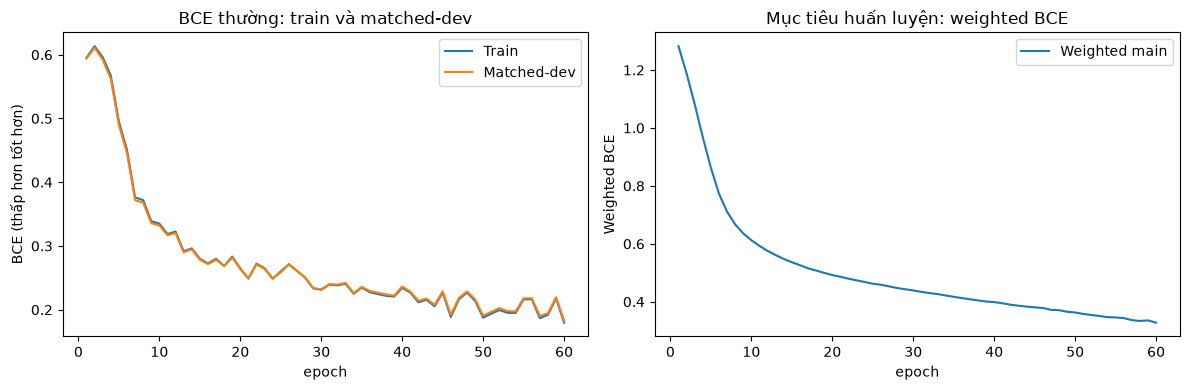

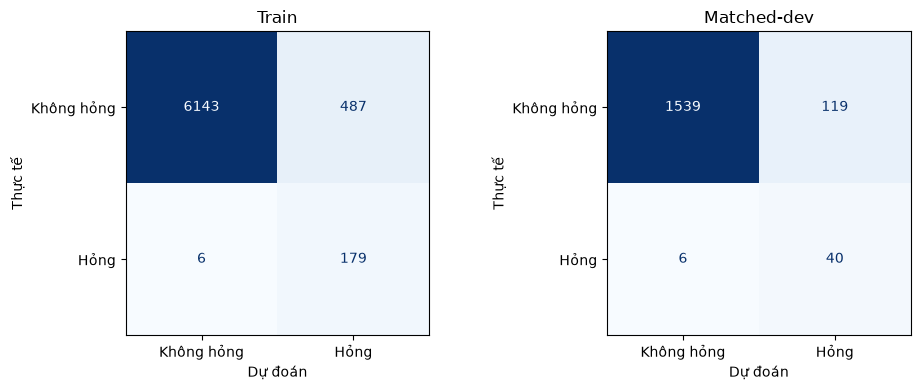

In [9]:
def predict_scores(model, name, multitask=False):
    model.eval()
    with torch.no_grad():
        output = model(X[name])
        logits = output[0] if multitask else output
        return torch.sigmoid(logits).numpy()

def binary_metrics(truth, scores):
    predicted = (scores >= THRESHOLD).astype(int)
    return {
        "BCE": log_loss(truth, scores, labels=[0, 1]),
        "Accuracy": accuracy_score(truth, predicted),
        "Precision": precision_score(truth, predicted, zero_division=0),
        "Recall": recall_score(truth, predicted, zero_division=0),
        "F1": f1_score(truth, predicted, zero_division=0),
        "AP": average_precision_score(truth, scores),
    }

single_scores = {name: predict_scores(single_model, name) for name in ["Train", "Matched-dev"]}
a_results = pd.DataFrame({
    name: binary_metrics(y[name].numpy(), scores) for name, scores in single_scores.items()
}).T
display(a_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
single_history[["Train", "Matched-dev"]].plot(ax=axes[0], title="BCE thường: train và matched-dev")
axes[0].set_ylabel("BCE (thấp hơn tốt hơn)")
single_history[["Weighted main"]].plot(ax=axes[1], title="Mục tiêu huấn luyện: weighted BCE")
axes[1].set_ylabel("Weighted BCE")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Train", "Matched-dev"]):
    ConfusionMatrixDisplay.from_predictions(
        y[name].numpy(), single_scores[name] >= THRESHOLD,
        labels=[0, 1], display_labels=["Không hỏng", "Hỏng"],
        ax=ax, colorbar=False, cmap="Blues",
    )
    ax.set(title=name, xlabel="Dự đoán", ylabel="Thực tế")
plt.tight_layout()
plt.show()

### Đọc kết quả A

Ưu tiên recall nếu mục tiêu là phát hiện failure, nhưng luôn đọc kèm precision và số FP:
hệ thống báo hỏng cho mọi máy sẽ có recall 100% mà không hữu ích.
Loss train giảm nhưng loss matched-dev tăng kéo dài là dấu hiệu overfitting.
Nếu cả hai đều cao, cần xem khả năng chưa học đủ hoặc mô hình/feature chưa phù hợp.
Không so trực tiếp độ lớn weighted BCE với BCE thường vì chúng là hai công thức khác nhau.

Ở **matched-dev**, accuracy = **92.7%**, recall = **87.0%**, precision = **25.2%**. Mạng bỏ sót **6/46** máy hỏng và tạo **119** báo động giả. Mốc luôn đoán không hỏng có accuracy **97.3%** nhưng recall **0%**. Đây là lý do accuracy một mình không đủ.

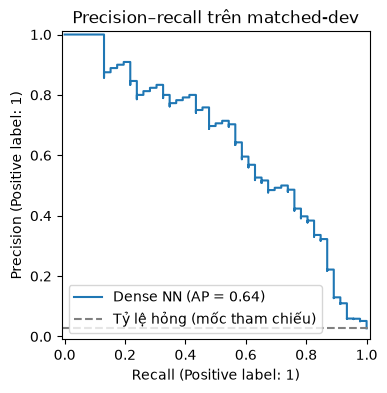

In [10]:
row = a_results.loc["Matched-dev"]
truth = y["Matched-dev"].numpy()
predicted = single_scores["Matched-dev"] >= THRESHOLD
missed = int(((truth == 1) & ~predicted).sum())
false_alarms = int(((truth == 0) & predicted).sum())
display(Markdown(
    f"Ở **matched-dev**, accuracy = **{row['Accuracy']:.1%}**, recall = **{row['Recall']:.1%}**, "
    f"precision = **{row['Precision']:.1%}**. Mạng bỏ sót **{missed}/{int(truth.sum())}** máy hỏng "
    f"và tạo **{false_alarms}** báo động giả. Mốc luôn đoán không hỏng có accuracy "
    f"**{1 - truth.mean():.1%}** nhưng recall **0%**. Đây là lý do accuracy một mình không đủ."
))

PrecisionRecallDisplay.from_predictions(truth, single_scores["Matched-dev"], name="Dense NN")
plt.axhline(truth.mean(), linestyle="--", color="gray", label="Tỷ lệ hỏng (mốc tham chiếu)")
plt.title("Precision–recall trên matched-dev")
plt.legend()
plt.show()

## B. Khi phân phối triển khai khác train

Bây giờ mới dùng mismatched-dev. Không huấn luyện lại mạng phần A.
Trước tiên kiểm tra mismatch có thật sự được tạo ra không bằng biểu đồ độ mòn và tỷ lệ nhóm.
Histogram dùng mật độ để so sánh hình dạng khi số mẫu giữa các tập khác nhau.

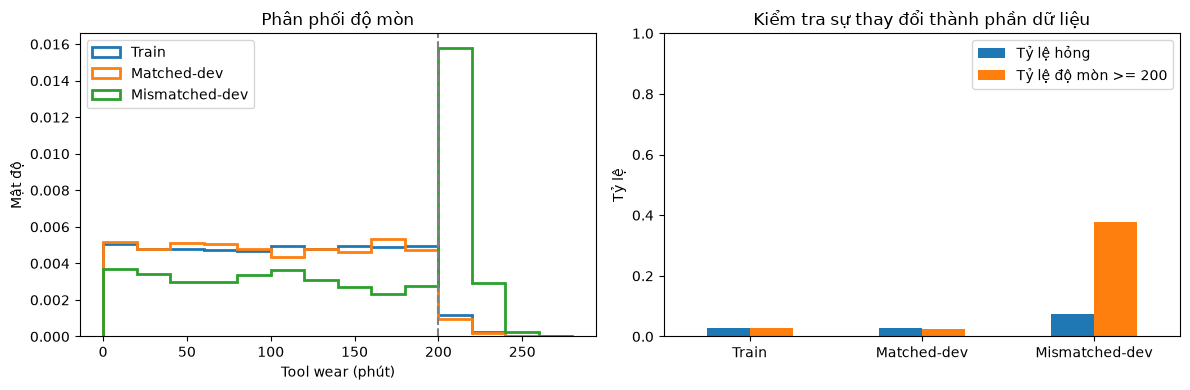

,BCE,Accuracy,Precision,Recall,F1,AP
Train,0.1797,0.9277,0.2688,0.9676,0.4207,0.6652
Matched-dev,0.1827,0.9266,0.2516,0.8696,0.3902,0.6364
Mismatched-dev,0.4001,0.7792,0.2283,0.8519,0.3601,0.6233


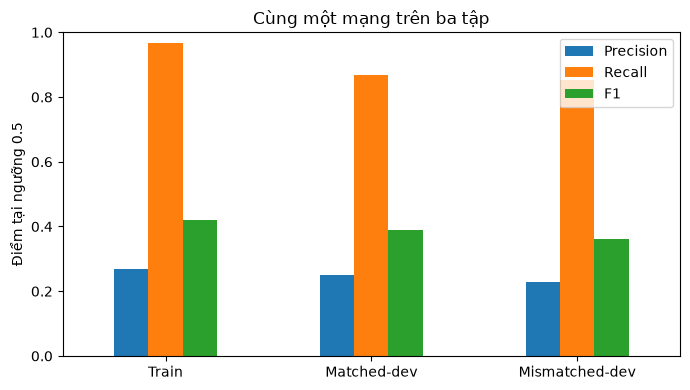

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.arange(0, 281, 20)  # Các khoảng 20 phút chỉ để biểu diễn histogram dễ đọc.
for name, frame in splits.items():
    axes[0].hist(frame["Tool wear [min]"], bins=bins, density=True,
                 histtype="step", linewidth=2, label=name)
axes[0].axvline(200, color="gray", linestyle="--")
axes[0].set(title="Phân phối độ mòn", xlabel="Tool wear (phút)", ylabel="Mật độ")
axes[0].legend()
split_summary[["Tỷ lệ hỏng", "Tỷ lệ độ mòn >= 200"]].plot.bar(ax=axes[1], rot=0)
axes[1].set(title="Kiểm tra sự thay đổi thành phần dữ liệu", ylabel="Tỷ lệ", ylim=(0, 1))
plt.tight_layout()
plt.show()

single_scores["Mismatched-dev"] = predict_scores(single_model, "Mismatched-dev")
b_results = pd.DataFrame({
    name: binary_metrics(y[name].numpy(), single_scores[name]) for name in splits
}).T
display(b_results.round(4))
b_results[["Precision", "Recall", "F1"]].plot.bar(rot=0, ylim=(0, 1), title="Cùng một mạng trên ba tập")
plt.ylabel("Điểm tại ngưỡng 0.5")
plt.tight_layout()
plt.show()

### Phân biệt high variance và mismatch

| Quan sát | Diễn giải có cơ sở |
|---|---|
| Train tốt, matched-dev kém rõ rệt | Gợi ý high variance: mô hình không khái quát tốt ngay cả khi phân phối gần nhau. |
| Train và matched-dev gần nhau, mismatched-dev kém hơn | Phù hợp với vấn đề mismatch; đối chiếu thêm thành phần nhóm và số mẫu hỏng. |
| Cả train và hai dev đều kém | Chưa đủ cơ sở quy cho mismatch; xem việc học và feature trước. |
| Mismatched-dev bằng hoặc tốt hơn matched-dev | Phân phối vẫn khác, nhưng chưa thấy tác hại theo metric đó; nhóm được giữ lại có thể dễ dự đoán hơn. |

Hai vấn đề có thể cùng xuất hiện. Không có một ngưỡng chênh lệch cố định đủ để chẩn đoán.
Tỷ lệ failure thay đổi cũng tác động đến precision/AP. Bảng theo nhóm dưới giúp tránh
nhầm thay đổi thành phần dữ liệu với việc mô hình kém hơn ở mọi nhóm.

In [12]:
gap = pd.DataFrame({
    "Matched-dev trừ Train": b_results.loc["Matched-dev"] - b_results.loc["Train"],
    "Mismatched-dev trừ Matched-dev": b_results.loc["Mismatched-dev"] - b_results.loc["Matched-dev"],
}).T
display(gap[["BCE", "Precision", "Recall", "F1"]].round(4))
print("BCE: chênh lệch dương là xấu hơn. Precision/recall/F1: chênh lệch âm là xấu hơn.")

group_rows = []
for name, frame in splits.items():
    for is_high, label in [(False, "< 200 phút"), (True, ">= 200 phút")]:
        mask = ((frame["Tool wear [min]"] >= 200) == is_high).to_numpy()
        result = binary_metrics(y[name].numpy()[mask], single_scores[name][mask])
        group_rows.append({"Tập": name, "Độ mòn": label, "Số mẫu": int(mask.sum()),
                           "Số hỏng": int(y[name].numpy()[mask].sum()), **result})
group_results = pd.DataFrame(group_rows).set_index(["Tập", "Độ mòn"])
display(group_results[["Số mẫu", "Số hỏng", "Precision", "Recall", "F1"]].round(3))

recall_gap = b_results.loc["Mismatched-dev", "Recall"] - b_results.loc["Matched-dev", "Recall"]
observation = "giảm" if recall_gap < 0 else "tăng hoặc giữ nguyên"
display(Markdown(
    f"Trong lần chạy này, recall trên mismatched-dev **{observation}** so với matched-dev "
    f"(chênh lệch **{100 * recall_gap:+.1f} điểm phần trăm**). "
    "Đây là quan sát của một phép chia dữ liệu; cần đọc cùng BCE, precision, F1 và số failure từng nhóm, "
    "không tự động kết luận mọi thay đổi đều do mismatch."
))

,BCE,Precision,Recall,F1
Matched-dev trừ Train,0.0030,-0.0172,-0.0980,-0.0304
Mismatched-dev trừ Matched-dev,0.2174,-0.0233,-0.0177,-0.0302


BCE: chênh lệch dương là xấu hơn. Precision/recall/F1: chênh lệch âm là xấu hơn.


Số mẫu  Số hỏng  Precision  Recall     F1
Tập            Độ mòn                                                
Train          < 200 phút     6616      155      0.274   0.974  0.428
               >= 200 phút     199       30      0.243   0.933  0.386
Matched-dev    < 200 phút     1663       39      0.244   0.846  0.379
               >= 200 phút      41        7      0.292   1.000  0.452
Mismatched-dev < 200 phút      920       22      0.304   0.955  0.462
               >= 200 phút     561       86      0.213   0.826  0.338

Trong lần chạy này, recall trên mismatched-dev **giảm** so với matched-dev (chênh lệch **-1.8 điểm phần trăm**). Đây là quan sát của một phép chia dữ liệu; cần đọc cùng BCE, precision, F1 và số failure từng nhóm, không tự động kết luận mọi thay đổi đều do mismatch.

### Hai cách xử lý mismatch được đề xuất

1. **Bổ sung dữ liệu train đại diện cho vận hành có độ mòn cao.** Đây là nhóm ta cố ý
   giữ lại nhiều trong dev; thêm các mẫu vận hành mới có nhãn giúp mạng học vùng này tốt hơn.
   Giữ nguyên dev để đánh giá, không chuyển mẫu dev đã xem vào train rồi báo lại điểm trên nó.
2. **Lấy mẫu lại nhóm độ mòn cao trong train theo tỷ lệ triển khai dự kiến.** Khi chưa thể
   thu thập dữ liệu mới, tăng tần suất gặp các mẫu sẵn có của nhóm này có thể giúp mục tiêu học
   gần môi trường triển khai hơn. Cách này không tạo thông tin mới và có thể gây overfitting.

Đây là xử lý **mất cân đối nhóm điều kiện vận hành**, khác với `pos_weight` đang xử lý
**mất cân bằng nhãn hỏng/không hỏng**. Chỉ ưu tiên thử khi môi trường thực tế có mismatch tương ứng;
đề yêu cầu đề xuất nên notebook chưa thêm một vòng thí nghiệm điều chỉnh nữa.

## C. Multi-task learning: cùng đầu vào, hai nhiệm vụ

Mạng dùng chung hai lớp Dense, rồi tách hai đầu ra:

```text
8 đặc trưng → Dense 32 → Dense 16 ┬→ 1 logit: máy có hỏng không?
                                └→ 6 logits: thuộc loại lỗi nào?
```

`Failure Type` là **nhãn để học**, không được nối vào X. Khi dự đoán, cả hai đầu
chỉ nhận đặc trưng vận hành. `No Failure` cũng là một lớp của nhiệm vụ phụ.
Vì hai nhiệm vụ liên quan, việc học phân biệt loại lỗi có thể giúp các lớp chung
học thông tin hữu ích cho phát hiện failure, nhưng không đảm bảo cải thiện.

Loss tổng = **weighted BCE của Target + 1.0 × cross-entropy của Failure Type**.
Hệ số 1.0 là điểm bắt đầu đơn giản, không phải hệ số tối ưu; hai loss có thể khác thang đo
và ảnh hưởng gradient dù hệ số bằng nhau. Ta dùng cross-entropy không trọng số cho nhãn phụ
để giữ thí nghiệm đơn giản, đồng thời kiểm tra nhược điểm: `No Failure` có thể lấn át các lớp hiếm.

Giữ nguyên split, preprocessing, số epoch, batch size, optimizer, ngưỡng và trọng số nhãn chính.
Cùng seed giúp phần chung và đầu nhãn chính khởi tạo giống baseline. Đầu phụ thêm một ít tham số,
nên đây là so sánh thực hành, chưa tách riêng ảnh hưởng của dung lượng mô hình.

In [13]:
type_encoder = LabelEncoder()
type_encoder.fit(train_df["Failure Type"])
y_type = {
    name: torch.tensor(type_encoder.transform(frame["Failure Type"]), dtype=torch.long)
    for name, frame in splits.items()
}
display(train_df["Failure Type"].value_counts().rename("Số mẫu train").to_frame())

class MultiTaskNN(DenseNN):
    def __init__(self, input_size, num_types):
        super().__init__(input_size)  # Cùng hai lớp ẩn và đầu dự đoán Target như baseline.
        self.type_head = nn.Linear(16, num_types)

    def forward(self, x):
        features = self.shared(x)
        return self.failure_head(features).squeeze(1), self.type_head(features)

torch.manual_seed(SEED)
multi_model = MultiTaskNN(X["Train"].shape[1], len(type_encoder.classes_))
multi_dataset = TensorDataset(X["Train"], y["Train"], y_type["Train"])
multi_history = train_model(multi_model, multi_dataset, multitask=True, aux_weight=1.0)

,Số mẫu train
Failure Type,
No Failure,6620
Heat Dissipation Failure,73
Power Failure,64
Overstrain Failure,30
Random Failures,16
Tool Wear Failure,12


Epoch 20: train BCE=0.2788, matched-dev BCE=0.2781


Epoch 40: train BCE=0.2496, matched-dev BCE=0.2494


Epoch 60: train BCE=0.2036, matched-dev BCE=0.2061


### So sánh nhiệm vụ chính trên đúng các tập cũ

Không so loss tổng của multi-task với loss của single-task: mô hình hai nhiệm vụ
phải trả thêm một thành phần loss. Bảng dưới luôn dùng **BCE thường của Target**.
Biểu đồ bên phải theo dõi riêng hai thành phần loss train của multi-task;
độ lớn loss chỉ là gợi ý về cân bằng nhiệm vụ, không đo trực tiếp mức chi phối gradient.

BCE  Accuracy  Precision  Recall      F1  \
Mô hình     Tập                                                           
Single-task Train           0.1797    0.9277     0.2688  0.9676  0.4207   
            Matched-dev     0.1827    0.9266     0.2516  0.8696  0.3902   
            Mismatched-dev  0.4001    0.7792     0.2283  0.8519  0.3601   
Multi-task  Train           0.2036    0.9187     0.2434  0.9459  0.3872   
            Matched-dev     0.2061    0.9196     0.2339  0.8696  0.3687   
            Mismatched-dev  0.4035    0.7792     0.2269  0.8426  0.3576   

                                AP  
Mô hình     Tập                     
Single-task Train           0.6652  
            Matched-dev     0.6364  
            Mismatched-dev  0.6233  
Multi-task  Train           0.6332  
            Matched-dev     0.6338  
            Mismatched-dev  0.5990

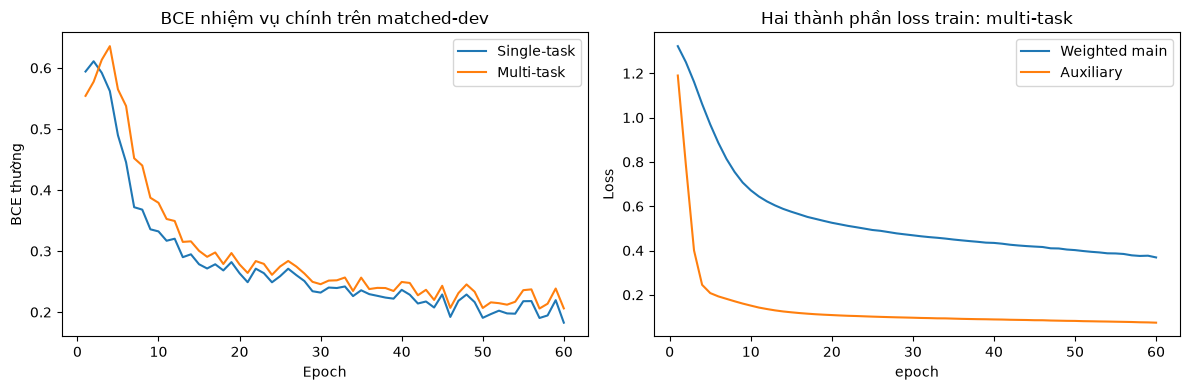

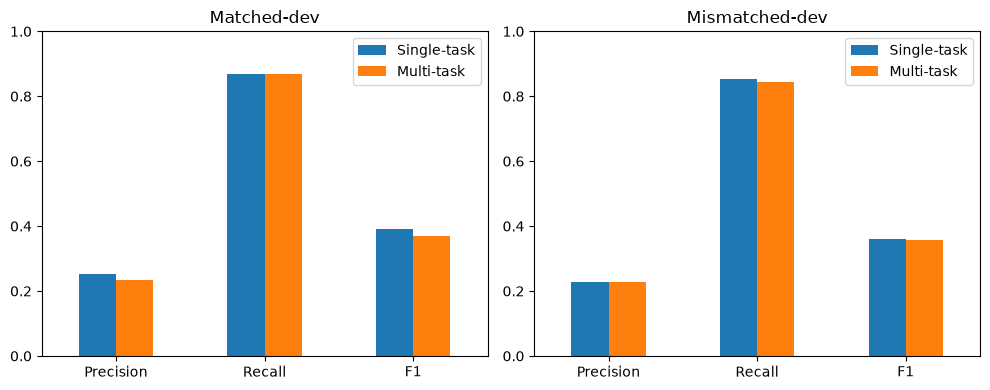

In [14]:
multi_scores = {name: predict_scores(multi_model, name, multitask=True) for name in splits}
c_results = pd.DataFrame({
    name: binary_metrics(y[name].numpy(), multi_scores[name]) for name in splits
}).T
comparison = pd.concat({"Single-task": b_results, "Multi-task": c_results}, names=["Mô hình", "Tập"])
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(single_history.index, single_history["Matched-dev"], label="Single-task")
axes[0].plot(multi_history.index, multi_history["Matched-dev"], label="Multi-task")
axes[0].set(title="BCE nhiệm vụ chính trên matched-dev", xlabel="Epoch", ylabel="BCE thường")
axes[0].legend()
multi_history[["Weighted main", "Auxiliary"]].plot(ax=axes[1], title="Hai thành phần loss train: multi-task")
axes[1].set_ylabel("Loss")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Matched-dev", "Mismatched-dev"]):
    pd.DataFrame({"Single-task": b_results.loc[name, ["Precision", "Recall", "F1"]],
                  "Multi-task": c_results.loc[name, ["Precision", "Recall", "F1"]]}).plot.bar(
        ax=ax, rot=0, ylim=(0, 1), title=name,
    )
plt.tight_layout()
plt.show()

### Nhiệm vụ phụ có học được các loại lỗi hiếm không?

Accuracy loại lỗi cao chưa đủ vì `No Failure` chiếm đa số. Xem recall từng loại và
**macro F1** (trung bình F1 với mỗi loại có trọng số ngang nhau) trong báo cáo bên dưới.
Một nhiệm vụ phụ chỉ giỏi dự đoán `No Failure` có thể cung cấp ít tín hiệu hữu ích.
Confusion matrix của Target trên hai dev cho biết lợi ích/thiệt hại cụ thể về FN và FP.

,precision,recall,f1-score,support
Heat Dissipation Failure,1.000,0.250,0.400,16.000
No Failure,0.983,0.999,0.991,1660.000
Overstrain Failure,0.000,0.000,0.000,9.000
Power Failure,0.833,0.588,0.690,17.000
Random Failures,0.000,0.000,0.000,1.000
Tool Wear Failure,0.000,0.000,0.000,1.000
accuracy,0.981,0.981,0.981,0.981
macro avg,0.469,0.306,0.347,1704.000
weighted avg,0.975,0.981,0.976,1704.000


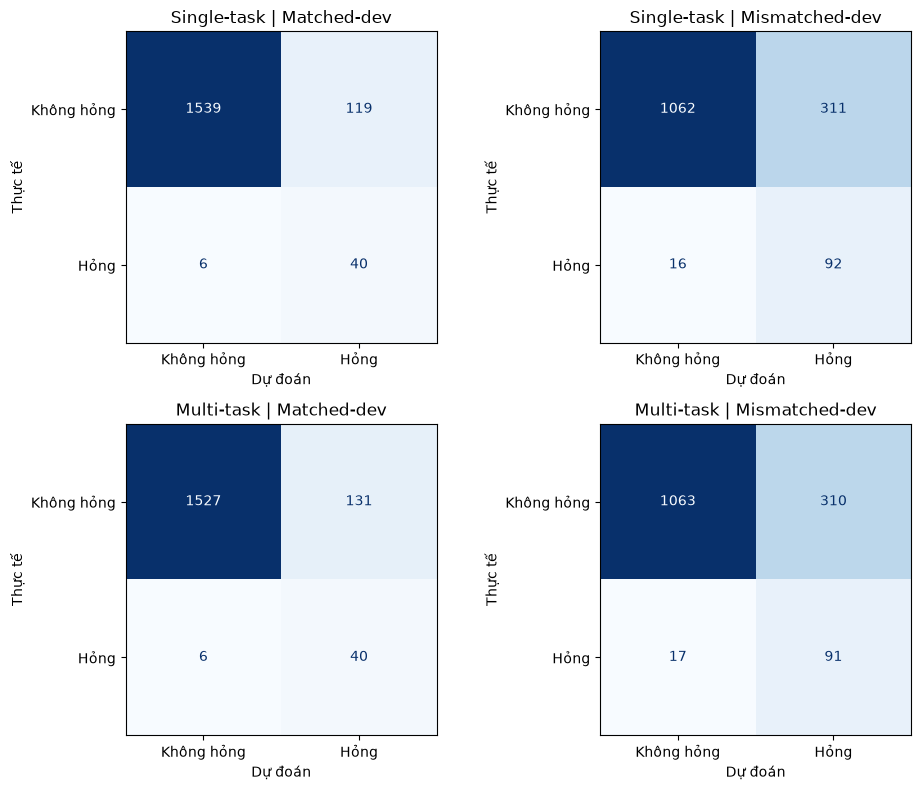

In [15]:
multi_model.eval()
with torch.no_grad():
    _, type_logits = multi_model(X["Matched-dev"])
    predicted_types = type_logits.argmax(dim=1).numpy()

type_report = classification_report(
    y_type["Matched-dev"].numpy(), predicted_types,
    labels=np.arange(len(type_encoder.classes_)), target_names=type_encoder.classes_,
    output_dict=True, zero_division=0,
)
display(pd.DataFrame(type_report).T.round(3))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for row_index, (model_name, scores) in enumerate([("Single-task", single_scores), ("Multi-task", multi_scores)]):
    for col_index, name in enumerate(["Matched-dev", "Mismatched-dev"]):
        ax = axes[row_index, col_index]
        ConfusionMatrixDisplay.from_predictions(
            y[name].numpy(), scores[name] >= THRESHOLD,
            labels=[0, 1], display_labels=["Không hỏng", "Hỏng"],
            ax=ax, cmap="Blues", colorbar=False,
        )
        ax.set(title=f"{model_name} | {name}", xlabel="Dự đoán", ylabel="Thực tế")
plt.tight_layout()
plt.show()

### Kết luận dựa trên lần chạy, không mặc định multi-task phải tốt hơn

Bảng chênh lệch bên dưới là **multi-task trừ single-task**. Recall tăng nhưng precision
giảm là đánh đổi, chưa thể gọi là tốt hơn nếu chưa biết chi phí bỏ sót và báo động giả.
Nếu recall và F1 cùng tăng trên dev, đó là tín hiệu hỗ trợ multi-task trong lần chạy này.

Nếu nhiệm vụ phụ không giúp, có ba khả năng cần phân tích theo đề:

- **Mức liên quan hữu ích:** hai nhãn có liên quan mạnh, nhưng một số dòng không nhất quán;
  loại lỗi có thể khó suy ra từ các cảm biến hiện có. Không nên kết luận “hai task không liên quan”
  chỉ vì kết quả không cải thiện.
- **Loss weighting:** hệ số 1.0 có thể chưa phù hợp. Nhìn đường loss để hình thành giả thuyết,
  sau đó mới thiết kế thí nghiệm thay hệ số trên matched-dev nếu cần.
- **Class imbalance:** nhãn phụ `No Failure` áp đảo; dùng báo cáo từng loại để xem mô hình có
  bỏ qua lỗi hiếm không. Trọng số lớp của nhãn chính không tự cân bằng nhãn phụ.

Một seed và một lần chia chưa đủ để chứng minh ưu thế tổng quát. Muốn kết luận chắc hơn,
cần lặp lại với vài seed và đánh giá cuối trên test chưa dùng cho chọn mô hình.

In [16]:
delta = c_results - b_results
display(delta.round(4))
for name in ["Matched-dev", "Mismatched-dev"]:
    d = delta.loc[name]
    if d["Recall"] > 0 and d["F1"] > 0:
        conclusion = "Recall và F1 cùng tăng: có tín hiệu nhiệm vụ phụ giúp trong lần chạy này."
    elif d["Recall"] < 0 and d["F1"] < 0:
        conclusion = "Recall và F1 cùng giảm: chưa thấy lợi ích từ nhiệm vụ phụ trong cấu hình này."
    else:
        conclusion = "Kết quả có đánh đổi hoặc không đổi; chưa thể kết luận multi-task tốt hơn."
    display(Markdown(
        f"**{name}:** Δrecall = {100*d['Recall']:+.1f} điểm %, "
        f"Δprecision = {100*d['Precision']:+.1f} điểm %, ΔF1 = {d['F1']:+.3f}. {conclusion}"
    ))

,BCE,Accuracy,Precision,Recall,F1,AP
Train,0.0239,-0.009,-0.0254,-0.0216,-0.0335,-0.0320
Matched-dev,0.0234,-0.007,-0.0177,0.0000,-0.0216,-0.0025
Mismatched-dev,0.0034,0.000,-0.0014,-0.0093,-0.0025,-0.0243


**Matched-dev:** Δrecall = +0.0 điểm %, Δprecision = -1.8 điểm %, ΔF1 = -0.022. Kết quả có đánh đổi hoặc không đổi; chưa thể kết luận multi-task tốt hơn.

**Mismatched-dev:** Δrecall = -0.9 điểm %, Δprecision = -0.1 điểm %, ΔF1 = -0.003. Recall và F1 cùng giảm: chưa thấy lợi ích từ nhiệm vụ phụ trong cấu hình này.

## Nhận xét về kết quả đã lưu

Các số dưới đây thuộc lần chạy kiểm tra đi kèm; nếu chạy lại, lấy bảng và nhận xét tự động phía trên làm căn cứ.

**A:** Baseline trên matched-dev có recall 86.96% và precision 25.16%: phát hiện 40/46 máy hỏng,
bỏ sót 6 máy và báo động giả 119 máy. Accuracy 92.66% thấp hơn mốc luôn đoán không hỏng,
nhưng mạng thực sự phát hiện được sự cố. Precision thấp cho thấy cần cân nhắc chi phí kiểm tra cảnh báo.

**B:** BCE train/matched-dev gần nhau (0.180/0.183), còn mismatched-dev tăng lên 0.400.
Nhóm độ mòn cao tăng từ khoảng 2.9% ở train lên 37.9% ở mismatched-dev. Điều này phù hợp với
ảnh hưởng của mismatch. Tuy nhiên, recall train 96.76% so với matched-dev 86.96% cho thấy vẫn có
khoảng cách khái quát hóa ở lớp hỏng; không thể nói hoàn toàn không có variance. Matched-dev chỉ có
46 mẫu hỏng nên một mẫu cũng làm recall thay đổi khoảng 2.17 điểm phần trăm.

**C:** Trên matched-dev, multi-task giữ nguyên recall 86.96% nhưng precision giảm còn 23.39%,
F1 giảm từ 0.390 xuống 0.369; trên mismatched-dev, recall và F1 cũng giảm nhẹ. Vì vậy cấu hình
này chưa cho thấy nhiệm vụ phụ giúp nhiệm vụ chính. Accuracy nhãn phụ khoảng 98.1% nhưng macro F1
chỉ khoảng 0.347; nhiều loại lỗi có recall bằng 0. Đây là bằng chứng cần chú ý mất cân bằng nhãn phụ,
còn loss weighting và tín hiệu chia sẻ hữu ích vẫn là giả thuyết cần thí nghiệm thêm.

## Những gì notebook đã trả lời

- **A:** Dense NN với feature hợp lệ; kiểm tra nhãn tiết lộ kết quả; train/dev loss,
  accuracy, precision, recall, F1, AP, đường học và confusion matrix.
- **B:** Hai dev có phân phối khác nhau được kiểm tra bằng hình; cùng một model được
  đánh giá trên ba tập; phân biệt variance/mismatch và đề xuất đúng hai hướng xử lý.
- **C:** Hai đầu ra dùng chung biểu diễn; cùng thiết lập để so với single-task;
  đánh giá nhiệm vụ chính, lớp lỗi hiếm và ba khả năng khi multi-task không giúp.

Dense NN được dùng vì yêu cầu đề và để mở rộng thuận tiện sang shared representation.
Notebook không chứng minh NN tốt hơn mô hình cây; muốn trả lời câu đó cần một thí nghiệm riêng.

**Tài liệu cho các thao tác chính:**
[Upload trên Colab](https://colab.research.google.com/notebooks/io.ipynb),
[chia stratified](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html),
[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html),
[weighted BCE](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.loss.BCEWithLogitsLoss.html).